In [1]:
pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip list

Package                   Version
------------------------- ----------------
absl-py                   2.4.0
altair                    6.0.0
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
astunparse                1.6.3
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
blinker                   1.9.0
cachetools                7.0.5
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
deep-sort-realtime        1.3.2
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("flight_delay.csv")

print(df.head())

         Date   Airline                      Origin    Destination  \
0  2026-05-21  SpiceJet  Pune International Airport  Delhi Airport   
1  2026-05-22  SpiceJet  Pune International Airport  Delhi Airport   
2  2026-05-23  SpiceJet  Pune International Airport  Delhi Airport   
3  2026-05-24  SpiceJet  Pune International Airport  Delhi Airport   
4  2026-05-25  SpiceJet  Pune International Airport  Delhi Airport   

  Scheduled_Departure Scheduled_Arrival Actual_Departure Actual_Arrival  \
0               05:55             08:30            08:09          10:04   
1               05:55             08:30            06:28          08:16   
2               05:55             08:30            11:55          12:55   
3               05:55             08:30            07:17          09:10   
4               05:55             08:30            06:19          08:16   

   Departure_Delay_Min  Arrival_Delay_Min  Delay_Duration_Min  
0                  134                 94                  94  


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
print(df.dtypes)

Date                   datetime64[us]
Airline                           str
Origin                            str
Destination                       str
Scheduled_Departure               str
Scheduled_Arrival                 str
Actual_Departure                  str
Actual_Arrival                    str
Departure_Delay_Min             int64
Arrival_Delay_Min               int64
Delay_Duration_Min              int64
dtype: object


In [5]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

print(df.head())

        Date   Airline                      Origin    Destination  \
0 2026-05-21  SpiceJet  Pune International Airport  Delhi Airport   
1 2026-05-22  SpiceJet  Pune International Airport  Delhi Airport   
2 2026-05-23  SpiceJet  Pune International Airport  Delhi Airport   
3 2026-05-24  SpiceJet  Pune International Airport  Delhi Airport   
4 2026-05-25  SpiceJet  Pune International Airport  Delhi Airport   

  Scheduled_Departure Scheduled_Arrival Actual_Departure Actual_Arrival  \
0               05:55             08:30            08:09          10:04   
1               05:55             08:30            06:28          08:16   
2               05:55             08:30            11:55          12:55   
3               05:55             08:30            07:17          09:10   
4               05:55             08:30            06:19          08:16   

   Departure_Delay_Min  Arrival_Delay_Min  Delay_Duration_Min  Day  Month  \
0                  134                 94                

In [6]:
X = df[['Day', 'Month', 'DayOfWeek', 'IsWeekend']]
y = df['Delay_Duration_Min']

In [7]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
future_date = pd.to_datetime('2026-06-17')

future_data = pd.DataFrame({
    'Day': [future_date.day],
    'Month': [future_date.month],
    'DayOfWeek': [future_date.dayofweek],
    'IsWeekend': [1 if future_date.dayofweek >= 5 else 0]
})

predicted_delay = model.predict(future_data)

print("Predicted Delay Duration:", round(predicted_delay[0],2), "minutes")

Predicted Delay Duration: 51.81 minutes


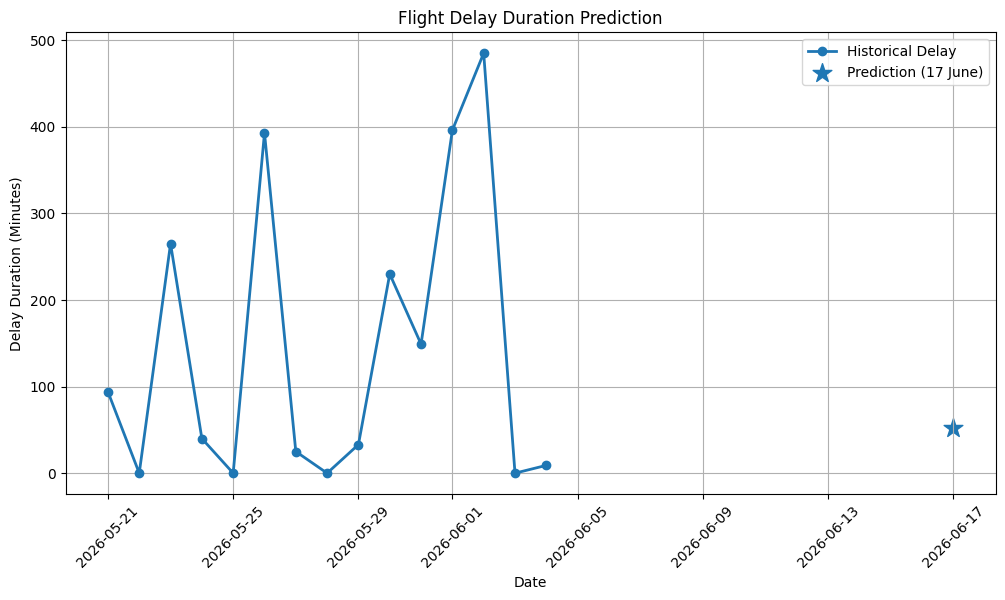

In [9]:
dates = list(df['Date'])
delays = list(df['Delay_Duration_Min'])

dates.append(future_date)
delays.append(predicted_delay[0])

plt.figure(figsize=(12,6))

plt.plot(
    dates[:-1],
    delays[:-1],
    marker='o',
    linewidth=2,
    label='Historical Delay'
)

plt.scatter(
    dates[-1],
    delays[-1],
    s=200,
    marker='*',
    label='Prediction (17 June)'
)

plt.title('Flight Delay Duration Prediction')
plt.xlabel('Date')
plt.ylabel('Delay Duration (Minutes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

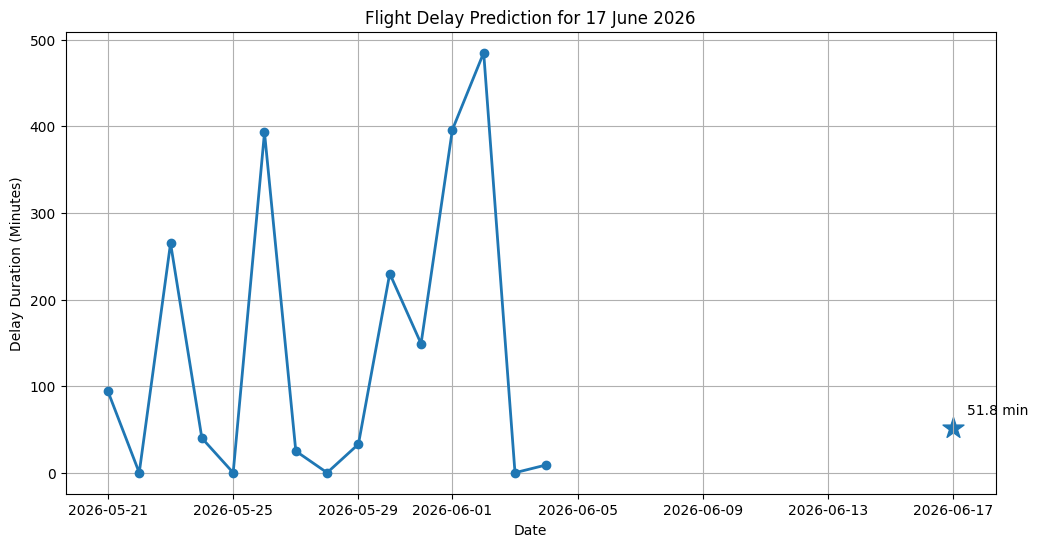

In [10]:
plt.figure(figsize=(12,6))

plt.plot(
    df['Date'],
    df['Delay_Duration_Min'],
    marker='o',
    linewidth=2
)

plt.scatter(
    future_date,
    predicted_delay[0],
    s=250,
    marker='*'
)

plt.annotate(
    f"{predicted_delay[0]:.1f} min",
    (future_date, predicted_delay[0]),
    xytext=(10,10),
    textcoords="offset points"
)

plt.title("Flight Delay Prediction for 17 June 2026")
plt.xlabel("Date")
plt.ylabel("Delay Duration (Minutes)")
plt.grid(True)

plt.show()

In [11]:
import pandas as pd

# Convert HH:MM to minutes
def time_to_minutes(t):
    h, m = map(int, t.split(':'))
    return h * 60 + m

df['Scheduled_Dep_Min'] = df['Scheduled_Departure'].apply(time_to_minutes)
df['Actual_Dep_Min'] = df['Actual_Departure'].apply(time_to_minutes)

comparison_table = df[['Date',
                       'Scheduled_Departure',
                       'Actual_Departure',
                       'Departure_Delay_Min']]

print(comparison_table)

         Date Scheduled_Departure Actual_Departure  Departure_Delay_Min
0  2026-05-21               05:55            08:09                  134
1  2026-05-22               05:55            06:28                   33
2  2026-05-23               05:55            11:55                  360
3  2026-05-24               05:55            07:17                   82
4  2026-05-25               05:55            06:19                   24
5  2026-05-26               05:55            13:07                  432
6  2026-05-27               05:55            07:02                   67
7  2026-05-28               05:55            06:24                   29
8  2026-05-29               05:55            07:10                   75
9  2026-05-30               05:55            10:28                  273
10 2026-05-31               05:55            09:05                  190
11 2026-06-01               05:55            13:11                  436
12 2026-06-02               05:55            14:49              

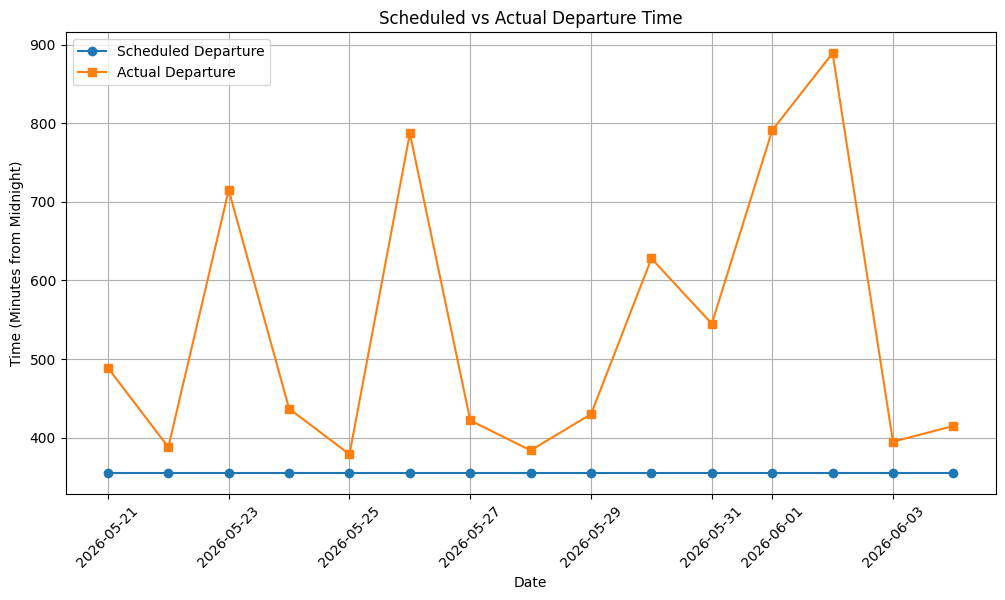

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    df['Date'],
    df['Scheduled_Dep_Min'],
    marker='o',
    label='Scheduled Departure'
)

plt.plot(
    df['Date'],
    df['Actual_Dep_Min'],
    marker='s',
    label='Actual Departure'
)

plt.title('Scheduled vs Actual Departure Time')
plt.xlabel('Date')
plt.ylabel('Time (Minutes from Midnight)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

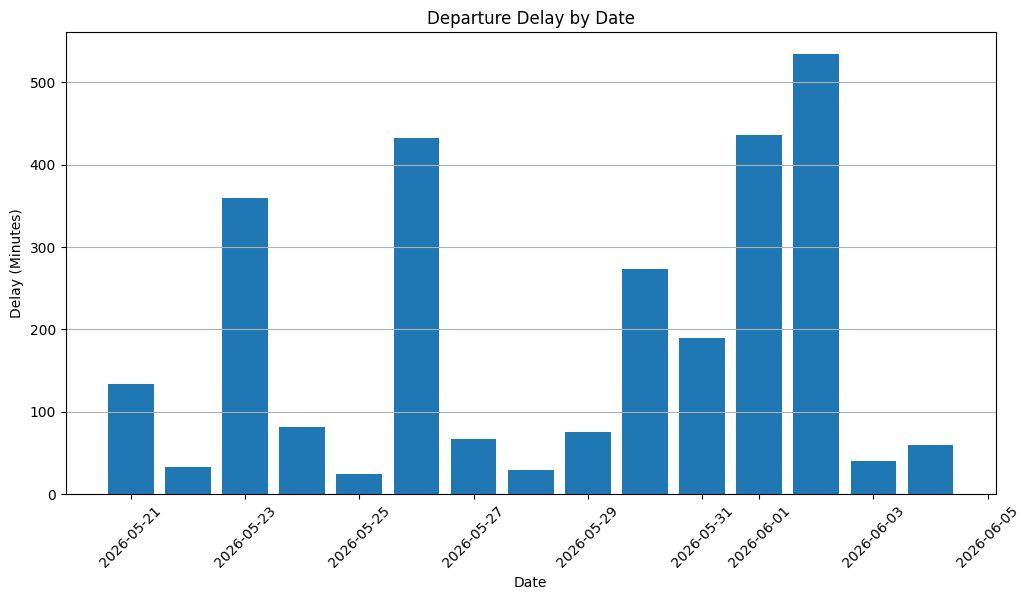

In [13]:
plt.figure(figsize=(12,6))

plt.bar(
    df['Date'],
    df['Departure_Delay_Min']
)

plt.title('Departure Delay by Date')
plt.xlabel('Date')
plt.ylabel('Delay (Minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()